# Plot Simulation Results

Unified plotting & reporting for the Qt–Ft simulations. Set everything in the **Settings** cell, then run the **Run** cell — it makes the plots **and** prints the summary **and** writes the data/table exports automatically.

Pick one of three modes:
- `MODE = "single"` — one finished single run (`trajectory.h5` under `Simulation_Files_Single_Runs/`)
- `MODE = "ensemble"` — one ensemble directory under `Different_Particle_Ratios/`
- `MODE = "comparison"` — several ensembles overlaid

Outputs go to a `Plots/` folder inside the run/ensemble directory (or `Plots_Comparison_<labels>/` for comparisons).

## 1. Imports

In [ ]:
import importlib
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import qtft
import qtft.config, qtft.system, qtft.engine
import qtft.analysis as analysis
import qtft.plotting as plotting
import qtft.comparison as ae
from qtft import SimulationConfig

# Dev helper: reload submodules after editing the qtft .py files (restart the kernel for deep changes).
for _m in (qtft.config, qtft.system, qtft.engine, qtft.analysis, qtft.plotting,
           qtft.comparison, qtft):
    importlib.reload(_m)
analysis = qtft.analysis
plotting = qtft.plotting
ae       = qtft.comparison
from qtft import SimulationConfig

print("qtft plotting/analysis/comparison modules loaded")

qtft plotting/analysis/comparison modules loaded


## 2. Settings

In [ ]:
# ============================================================
# PLOT SETTINGS  —  choose what to plot and where the data lives
# ============================================================
MODE = "ensemble"   # "single" | "ensemble" | "comparison"

BASE_DIR = "Simulation_Files_Ensembles"   # parent folder for ensembles / comparisons

# ----- MODE == "single": one finished single run -----
SINGLE_RUN_DIR = os.path.join(
    BASE_DIR, "200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us", 
)
SINGLE_H5     = None   # None -> auto-detect (<run>.h5, or trajectory_combined.h5 for phased runs)
SINGLE_CONFIG = None   # None -> auto-detect (<run>_config.json inside SINGLE_RUN_DIR)

# ----- MODE == "ensemble": one ensemble directory -----
ENSEMBLE_DIR = os.path.join(
    BASE_DIR, "200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us",
)

# ----- MODE == "comparison": several ensembles, {label: directory} -----
ENSEMBLES_TO_COMPARE = {
    "200 Qt 200 Ft":  os.path.join(BASE_DIR, "200Qt_200Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us"),
}

# ----- Plot options -----
SHOW_INDIVIDUAL = False   # ensemble panel: overlay individual replica traces
SHOW_BANDS      = None    # comparison: None = auto (bands for <= 3 ensembles); True/False to force
STRIDE          = 1       # single: frame stride for structural/composition analysis
EXPORT_XYZ      = False   # single: also export an OVITO .xyz (can be large/slow)

print(f"MODE = {MODE!r}")

MODE = 'ensemble'


## 3. Run — plots, summary & data export

✓ Loaded statistics from Simulation_Files_Ensembles/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_0.10us/ensemble_statistics.json
✓ Loaded structural data from Simulation_Files_Ensembles/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_0.10us/ensemble_structural.npz
✓ Loaded configuration from Simulation_Files_Ensembles/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_0.10us/ensemble_config.json
Ensemble: Simulation_Files_Ensembles/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_0.10us
Plots/exports -> Simulation_Files_Ensembles/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_0.10us/Plots/


Generating ensemble thesis panel...
✓ Saved panel to Simulation_Files_Ensembles/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_0.10us/Plots/ensemble_panel.svg
✓ Saved panel to Simulation_Files_Ensembles/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_0.10us/Plots/ensemble_panel.png


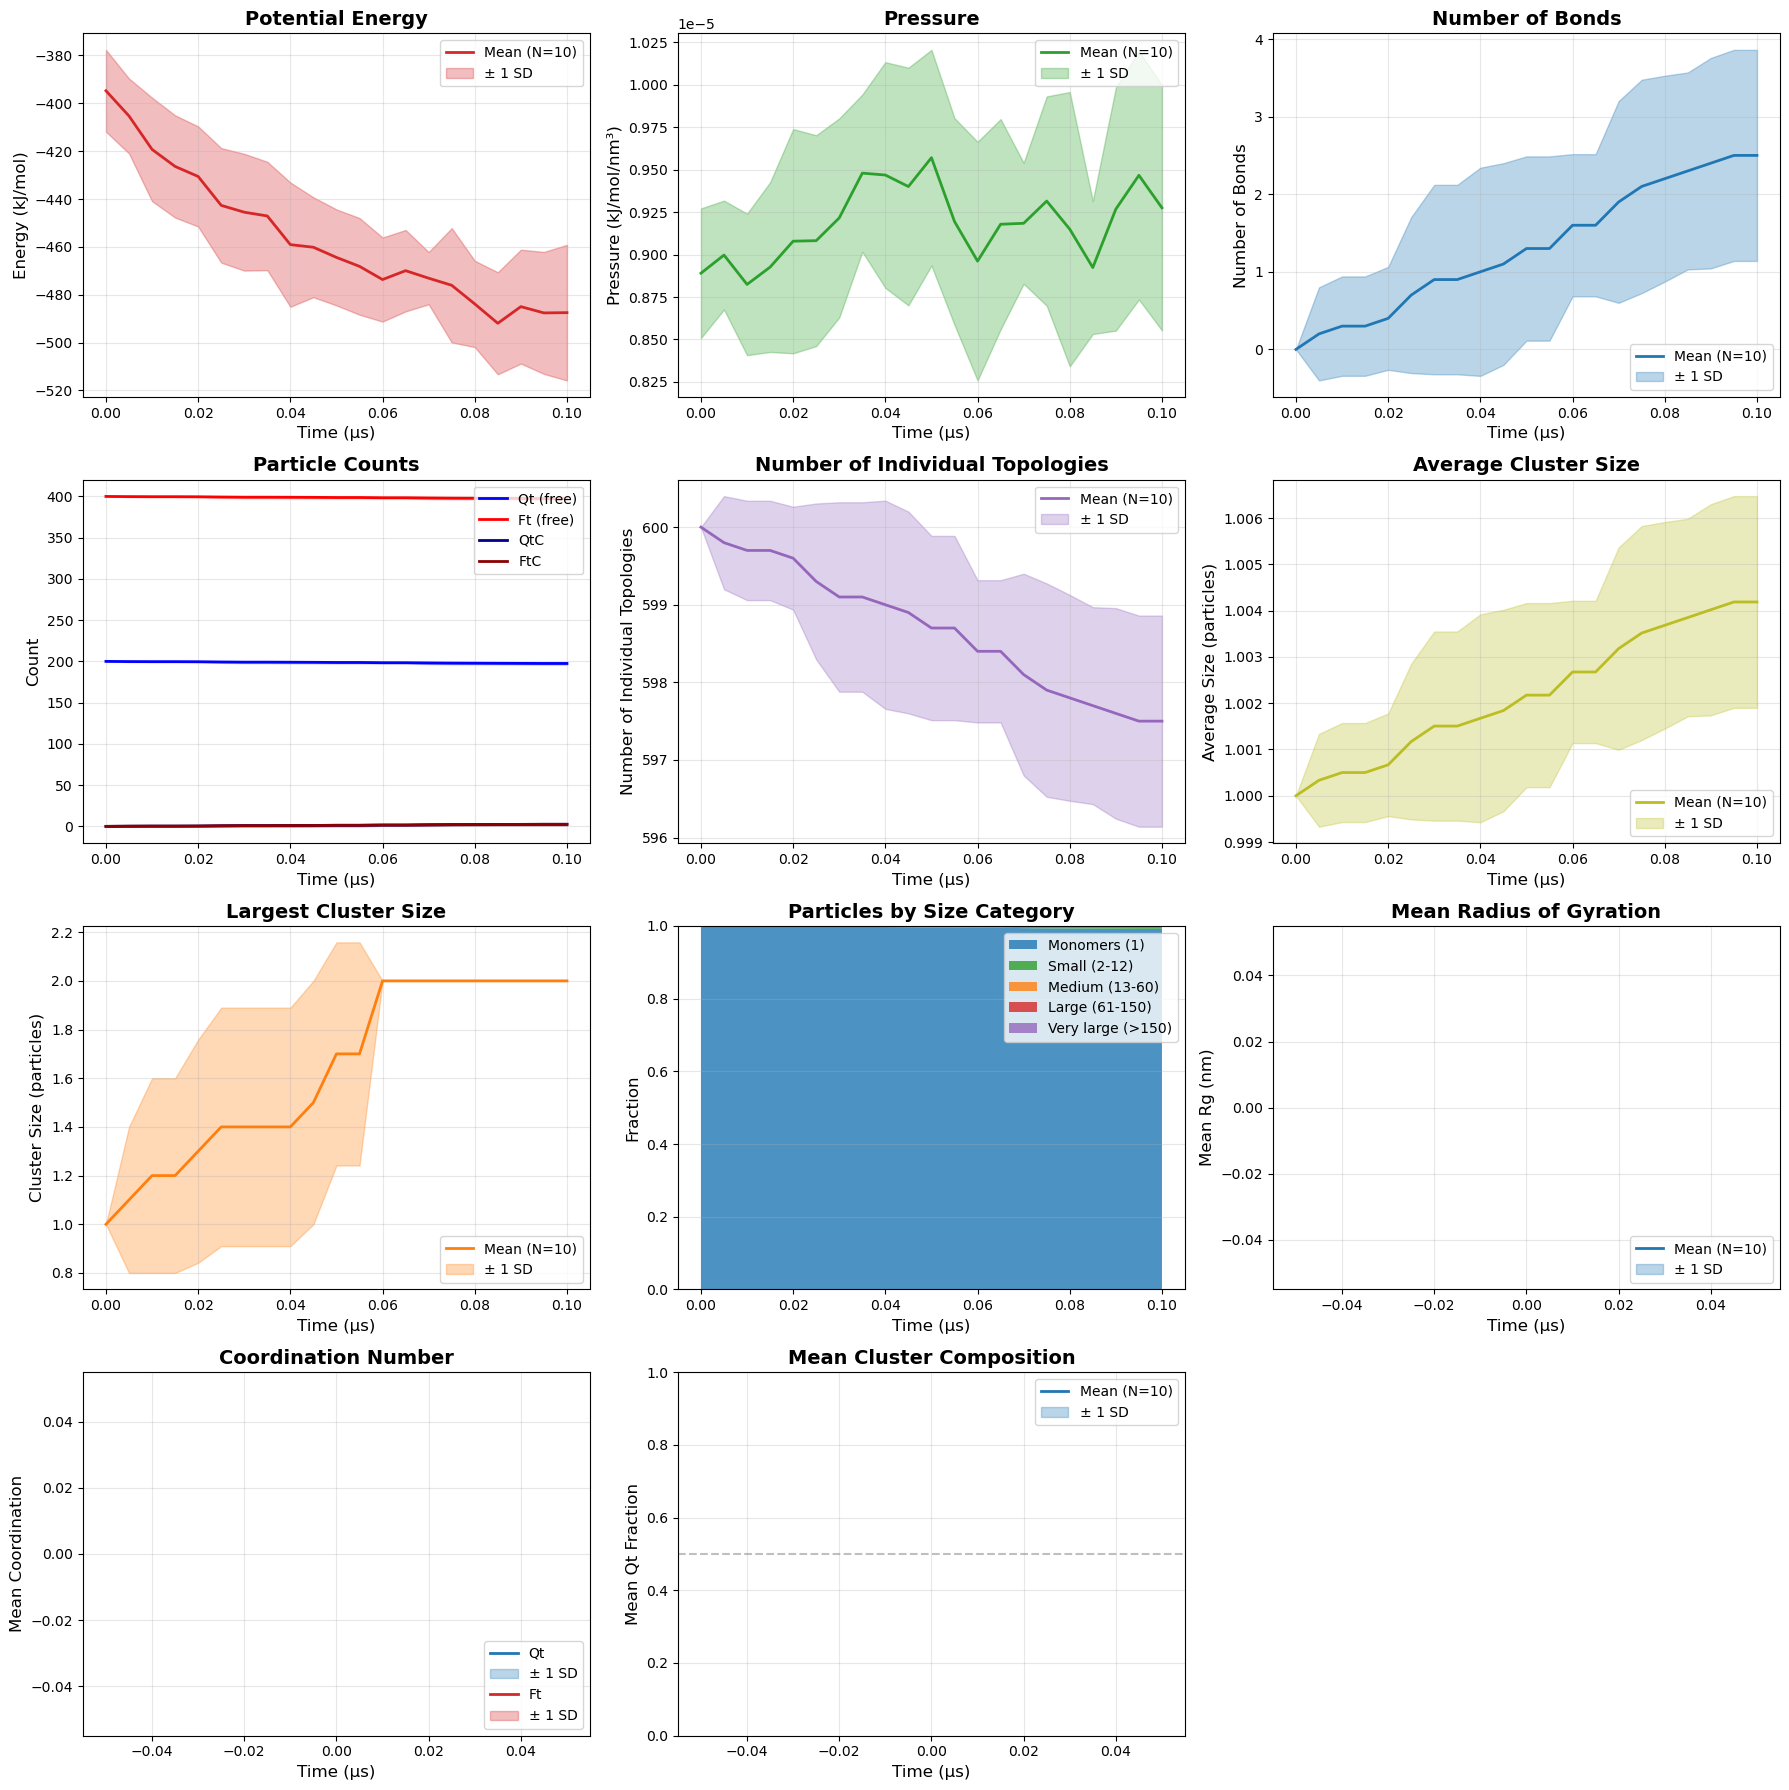


ENSEMBLE SUMMARY (N=10 replicas)

System: 200 Qt + 400 Ft particles

Final state metrics:
  Bonds: 2.5 ± 1.4
  Largest cluster: 0.3% ± 0.0% of particles
  Half-time: 0.05 ± 0.02 µs

✓ Saved table to Simulation_Files_Ensembles/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_0.10us/Plots/final_state_table.csv
✓ Saved table to Simulation_Files_Ensembles/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_0.10us/Plots/final_state_table.tex
Saved tables/CSV to Simulation_Files_Ensembles/200Qt_400Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_0.10us/Plots/


,Value,Unit
Metric,,
Number of bonds,2.5 ± 1.4,—
Individual topologies,597.5 ± 1.4,—
Average cluster size,1.0 ± 0.0,particles
Largest cluster size,2.0 ± 0.0,particles
Largest cluster fraction,0.3 ± 0.0,% of particles
Fraction bound,0.009 ± 0.005,—
Half-time t₅₀,0.05 ± 0.02,µs
Radius of gyration,0.0 ± 0.0,nm
Qt fraction (QtC/(QtC+FtC)),0.000 ± 0.000,—


In [7]:
# ============================================================
# RUN  —  plots + summary + data export, all driven by MODE
# ============================================================

if MODE == "single":
    run_name = os.path.basename(os.path.normpath(SINGLE_RUN_DIR))
    cfg_path = SINGLE_CONFIG or os.path.join(SINGLE_RUN_DIR, run_name + "_config.json")
    cfg = SimulationConfig.load_json(cfg_path)

    if SINGLE_H5:
        h5 = SINGLE_H5
    elif cfg.phases:
        h5 = os.path.join(SINGLE_RUN_DIR, "trajectory_combined.h5")
    else:
        h5 = os.path.join(SINGLE_RUN_DIR, run_name + ".h5")

    OUT = os.path.join(SINGLE_RUN_DIR, "Plots")
    os.makedirs(OUT, exist_ok=True)
    print(f"Single run: {h5}\nPlots/exports -> {OUT}/\n")

    # ----- Plots -----
    if cfg.phases:
        phase_files = sorted(glob.glob(os.path.join(SINGLE_RUN_DIR, "phase_*", "trajectory.h5")))
        plotting.plot_phased_kinetics(cfg, phase_files=phase_files or None,
                                      save_path=os.path.join(OUT, "phased_kinetics.svg"))
    else:
        plotting.plot_observables(h5, cfg, save_path=os.path.join(OUT, "observables.svg"))
        plotting.plot_cluster_analysis(h5, cfg, save_path=os.path.join(OUT, "clusters.svg"))
        plotting.plot_structural_cluster_analysis(h5, cfg, stride=STRIDE,
                                                  save_path=os.path.join(OUT, "structural.svg"))
        plotting.plot_cluster_composition(h5, cfg, stride=STRIDE,
                                          save_path=os.path.join(OUT, "composition.svg"))
    plt.show()

    # ----- Summary -----
    analysis.print_analysis_summary(h5, cfg)

    # ----- Data export (single runs have no ensemble-style table) -----
    cstats = analysis.get_cluster_statistics(h5)
    bonds  = analysis.get_bond_counts(h5, silent=True)
    f = cfg.timestep * 1e-3   # steps -> µs
    pd.DataFrame({
        "time_steps": cstats["times"],
        "time_us":    np.asarray(cstats["times"]) * f,
        "n_clusters": cstats["n_clusters"],
        "avg_size":   cstats["avg_sizes"],
        "max_size":   cstats["max_sizes"],
    }).to_csv(os.path.join(OUT, run_name + "_clusters.csv"), index=False)
    pd.DataFrame({
        "time_steps": bonds["times"],
        "time_us":    np.asarray(bonds["times"]) * f,
        "n_bonds":    bonds["n_bonds"],
    }).to_csv(os.path.join(OUT, run_name + "_bonds.csv"), index=False)
    print(f"Saved time-series CSVs to {OUT}/")

    if EXPORT_XYZ:
        xyz = os.path.join(OUT, run_name + ".xyz")
        analysis.convert_h5_to_xyz(h5, xyz, cfg, overwrite=True)
        print(f"Exported XYZ: {xyz}")

elif MODE == "ensemble":
    stats, structural, config = analysis.load_ensemble_data(ENSEMBLE_DIR)
    OUT = os.path.join(ENSEMBLE_DIR, "Plots")
    os.makedirs(OUT, exist_ok=True)
    print(f"Ensemble: {ENSEMBLE_DIR}\nPlots/exports -> {OUT}/\n")

    # ----- Plot (composite thesis panel: SVG + PNG) -----
    plotting.plot_ensemble_panel(stats, structural, config,
                               show_individual=SHOW_INDIVIDUAL,
                               save_path_base=os.path.join(OUT, "ensemble_panel"))
    plt.show()

    # ----- Summary -----
    analysis.print_ensemble_summary(stats, config)

    # ----- Data export: final-state table (.csv/.tex) + bonds time series -----
    df_summary = analysis.build_final_state_table(stats, config, structural)
    analysis.save_table_files(df_summary, os.path.join(OUT, "final_state_table"),
                              caption="Final-state summary (mean ± SD over replicas).",
                              label="tab:final_state")
    if "times" in stats and "bonds_mean" in stats:
        f = config.get("timestep", 0.001) * 1e-3
        pd.DataFrame({
            "time_steps": stats["times"],
            "time_us":    np.asarray(stats["times"]) * f,
            "bonds_mean": stats["bonds_mean"],
            "bonds_std":  stats.get("bonds_std", np.zeros_like(stats["bonds_mean"])),
        }).to_csv(os.path.join(OUT, "ensemble_bonds.csv"), index=False)
    print(f"Saved tables/CSV to {OUT}/")
    try:
        display(df_summary)
    except NameError:
        print(df_summary)

elif MODE == "comparison":
    comp = ae.compare_ensembles(ENSEMBLES_TO_COMPARE)
    _labels = "_".join(l.replace(" ", "") for l in comp["labels"])
    OUT = os.path.join(BASE_DIR, "Plots_Comparison_" + _labels)
    os.makedirs(OUT, exist_ok=True)
    print(f"Comparison of {comp['n_ensembles']} ensembles\nPlots/exports -> {OUT}/\n")

    # ----- Plots: comparison panel (SVG + PNG) + per-ensemble size categories -----
    plotting.plot_comparison_panel(comp, show_bands=SHOW_BANDS,
                                 save_path_base=os.path.join(OUT, "comparison_panel"))
    plotting.plot_comparison_size_categories(comp, save_dir=OUT)
    plt.show()

    # ----- Summary -----
    ae.print_parameter_differences(comp)

    # ----- Data export: comparison table (.csv/.tex) + raw comparison data -----
    df_compare = ae.build_comparison_table(comp)
    analysis.save_table_files(df_compare, os.path.join(OUT, "comparison_table"),
                              caption="Final-state comparison across ensembles (mean ± SD).",
                              label="tab:comparison")
    ae.save_comparison_data(comp, os.path.join(OUT, "comparison_data"))
    print(f"Saved tables/data to {OUT}/")
    try:
        display(df_compare)
    except NameError:
        print(df_compare)

else:
    raise ValueError(f"MODE must be 'single', 'ensemble', or 'comparison', got {MODE!r}")